In [26]:
from pathlib import Path
import sys
import importlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PROJECT = Path.cwd().parent

DATA = PROJECT / "data"
SRC = PROJECT / "src"
OUTPUT = PROJECT / "output"

sys.path.insert(0, str(SRC))

import maps

importlib.reload(maps)

maps_data = maps.prepare_regions(DATA)

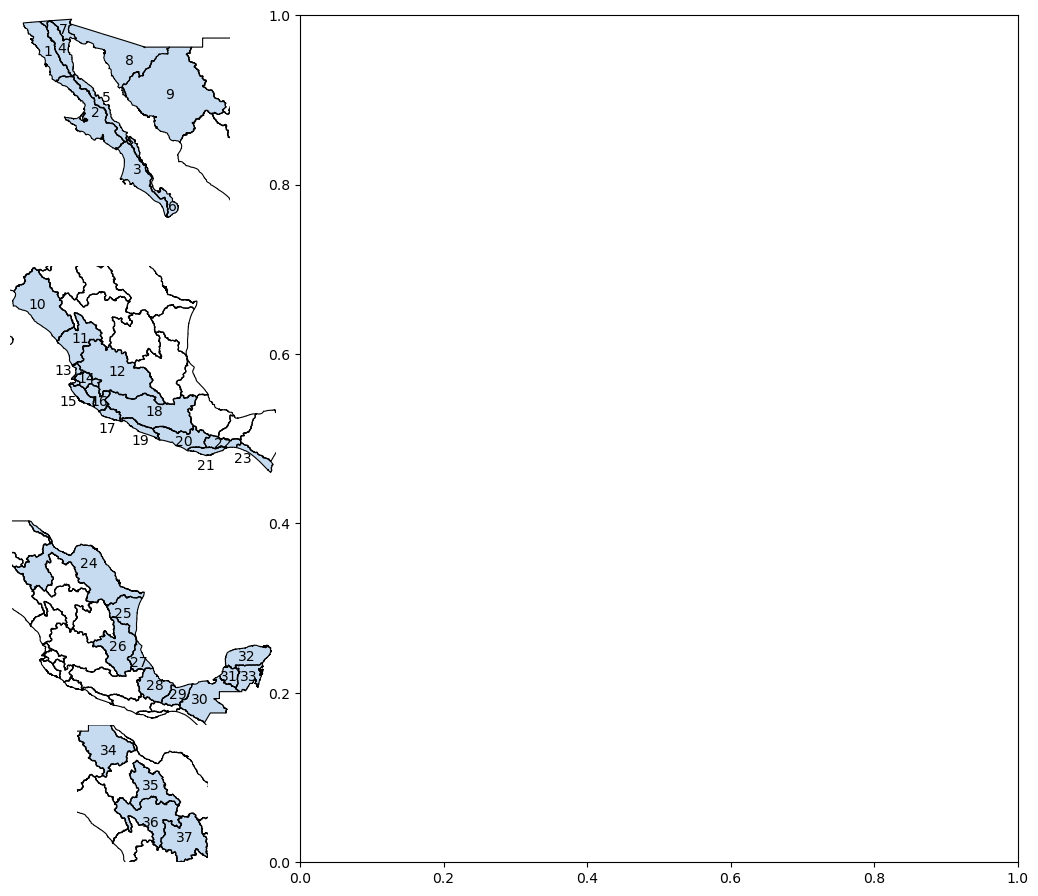

In [27]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# ------------------------------------------------------------
# Relative heights of the hydroclimatic domains
# ------------------------------------------------------------

#height_ratios = [
#    len(maps.DOMAINS["NW"]),
#    len(maps.DOMAINS["PC"]),
#    len(maps.DOMAINS["GC"]),
#    len(maps.DOMAINS["NC"]),
#]
# Relative heights used for the final figure layout.
# They are slightly adjusted from the number of Hydrological Regions
# to improve the visual balance among the four maps.
height_ratios = [9, 13, 9, 6]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(13, 11))

# Main layout: maps | heatmap
outer_gs = GridSpec(
    nrows=1,
    ncols=2,
    figure=fig,
    width_ratios=[1.0, 2.7],
    wspace=0.05,
)

# Left column (maps)
left_gs = GridSpecFromSubplotSpec(
    nrows=4,
    ncols=1,
    subplot_spec=outer_gs[0],
    height_ratios=height_ratios,
    hspace=0.0,
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax_nw = fig.add_subplot(left_gs[0])
ax_pc = fig.add_subplot(left_gs[1])
ax_gc = fig.add_subplot(left_gs[2])
ax_nc = fig.add_subplot(left_gs[3])

ax_heat = fig.add_subplot(outer_gs[1])

# ------------------------------------------------------------
# Draw maps
# ------------------------------------------------------------

maps.plot_domain(ax_nw, maps_data, "NW", mx=0.02, my=0.02)
maps.plot_domain(ax_pc, maps_data, "PC", mx=0.01, my=0.01)
maps.plot_domain(ax_gc, maps_data, "GC", mx=0.01, my=0.01)
maps.plot_domain(ax_nc, maps_data, "NC", mx=0.00, my=0.00)

# Move the NW map slightly to the left
pos = ax_nw.get_position()
ax_nw.set_position([
    pos.x0 - 0.014,   # adjust this value
    pos.y0,
    pos.width,
    pos.height
])

In [28]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ==========================================================
# Continuous diverging colormap
# Dark Red → White → Dark Green
# ==========================================================

n = 100

# Base colors (same as MATLAB)
red_dark   = np.array([0.55, 0.10, 0.10])
white      = np.array([1.00, 1.00, 1.00])
green_dark = np.array([0.00, 0.50, 0.00])

# ----------------------------------------------------------
# Adjustable width of the central white band
# ----------------------------------------------------------

white_frac = 0.05      # Fraction of the colormap occupied by white

n_white = round(n * white_frac / 2)
n_half  = n // 2 - n_white

# ----------------------------------------------------------
# Dark red → white
# ----------------------------------------------------------

reds_to_white = np.column_stack([
    np.linspace(red_dark[i], white[i], n_half)
    for i in range(3)
])

# ----------------------------------------------------------
# Central white band
# ----------------------------------------------------------

white_band = np.tile(white, (2 * n_white, 1))

# ----------------------------------------------------------
# White → dark green
# ----------------------------------------------------------

white_to_green = np.column_stack([
    np.linspace(white[i], green_dark[i], n_half)
    for i in range(3)
])

# ----------------------------------------------------------
# Final colormap
# ----------------------------------------------------------

colors = np.vstack([
    reds_to_white,
    white_band,
    white_to_green
])

cmap_use = LinearSegmentedColormap.from_list(
    "trend",
    colors,
    N=256
)

print(cmap_use.N)

256


In [29]:
# ==========================================================
# Heatmap data 
# ==========================================================

from scipy.io import loadmat
from matplotlib.colors import ListedColormap

# Read CHIRPS precipitation
mat = loadmat(DATA / "PPT_CHIRPS_81_24.mat")
PPT = mat["PPT_CHIRPS_81_24"]

# Read p-values
mat = loadmat(DATA / "p_value_PPT_CHIRPS_81_24.mat")
p_value = mat["p_value_PPT_CHIRPS_81_24"]
# Keep only the first 24 fortnights and match M dimensions
p_value = p_value[:, :24].T

print(p_value.shape)

# Select year 45 (index 44)
M = PPT[:, 44, :]

# Keep the first 24 fortnights
M = M[:24, :]

print("PPT:", PPT.shape)
print("p_value:", p_value.shape)
print("M:", M.shape)

(24, 37)
PPT: (25, 46, 37)
p_value: (24, 37)
M: (24, 37)


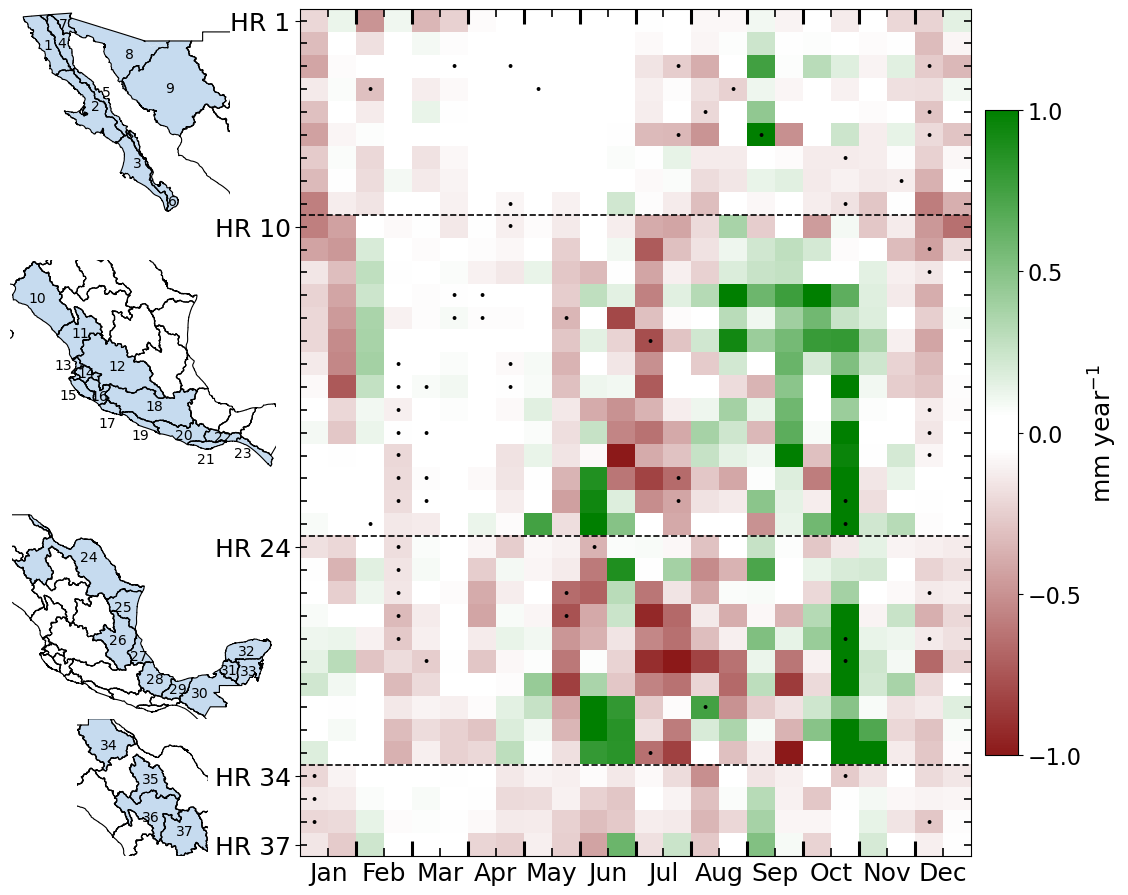

In [30]:
# ==========================================
# heatmap significant trends
# ==========================================

from matplotlib.colors import TwoSlopeNorm

#Limits
norm = TwoSlopeNorm(
    vmin=-1,
    vcenter=0,
    vmax=1
)
# Trends
im = ax_heat.imshow(
    M.T,
    cmap=cmap_use,
    norm=norm,
    origin="upper",
    aspect="auto",
    interpolation="nearest"
)
ax_heat.set_xlim(-0.5, 23.5)
ax_heat.set_ylim(36.5, -0.5)

# ==========================================
# Axe X 
# ==========================================

months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# Ticks 
ax_heat.set_xticks(np.arange(0.5, 24, 2))
ax_heat.set_xticklabels(months, fontsize=18)

ax_heat.tick_params(
    axis="x",
    which="major",
    direction="in",
    top=True,
    bottom=True,
    length=6,
    width=1.2,
)
# ==========================================
# Ticks 
# ==========================================

ymin, ymax = ax_heat.get_ylim()

L = 0.65

for x in np.arange(1.5, 23, 2):

    # Tick superior
    ax_heat.plot(
        [x, x],
        [ymax, ymax + L],
        color="black",
        lw=2.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )

    # Tick inferior
    ax_heat.plot(
        [x, x],
        [ymin, ymin - L],
        color="black",
        lw=2.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )
# ==========================================
# Axe Y (HR)
# ==========================================

ax_heat.set_yticks([0,9,23,33,36])

ax_heat.set_yticklabels(
    ["HR 1","HR 10","HR 24","HR 34","HR 37"],
    fontsize=18
)
# ==========================================
# Ticks 
# ==========================================

xmin, xmax = ax_heat.get_xlim()

L = 0.25

for y in np.arange(37):

    # Tick left
    ax_heat.plot(
        [xmin, xmin + L],
        [y, y],
        color="black",
        lw=1.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )

    # Tick right
    ax_heat.plot(
        [xmax, xmax - L],
        [y, y],
        color="black",
        lw=1.2,
        solid_capstyle="butt",
        clip_on=True,
        zorder=10,
    )

#ax_heat.set_xlabel("Fortnights", fontsize=16)
#ax_heat.set_ylabel("Hydrological Regions", fontsize=16)
# ==========================================
# Dividers
# ==========================================

for y in [8.5, 22.5, 32.5]:
    ax_heat.axhline(
        y,
        color="black",
        linestyle="--",
        linewidth=1.2
    )
# ==========================================================
# Add significance markers (p < 0.05)
# ==========================================================

for i in range(M.shape[0]):      # Fortnights (24)
    for j in range(M.shape[1]):  # Hydrological regions (37)

        if p_value[i, j] < 0.05:

            ax_heat.text(
                i,                  # x-coordinate (fortnight)
                j,                  # y-coordinate (region)
                "•",
                ha="center",
                va="center",
                color="black",
                fontsize=8,
                fontweight="bold",
                zorder=20,
            )
# ==========================================
# Colorbar (continuous)
# ==========================================
cbar = fig.colorbar(
    im,
    ax=ax_heat,
    fraction=0.045,
    pad=0.02,
)

cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

cbar.set_label(
    r"mm year$^{-1}$",
    fontsize=18
)

cbar.ax.tick_params(labelsize=16)

fig


In [31]:
# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

fig.savefig(
    OUTPUT / "Figure_06_trends.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    OUTPUT / "Figure_06_trends.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()